## Trabalho 3 - Geracao e recepcao de sinais FSK

Este notebook simula um sistema BFSK simples.

No BFSK, cada bit e representado por uma frequencia diferente:

- bit `0` -> frequencia `f0`
- bit `1` -> frequencia `f1`

In [1]:
# Instala as bibliotecas usadas na simulacao.
!pip install numpy
!pip install matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: C:\Users\eduar\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: C:\Users\eduar\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [2]:
# Biblioteca para operacoes numericas e vetores.
import numpy as np

# Biblioteca para gerar os graficos do sinal.
import matplotlib.pyplot as plt

# Fixa a semente aleatoria para obter sempre a mesma sequencia de bits.
np.random.seed(10)

### Parametros do sistema

In [3]:
# Numero de bits que serao transmitidos.
N_bits = 10

# Duracao de cada bit, em segundos.
Tb = 1

# Frequencia de amostragem usada para representar o sinal no computador.
fs = 200

# Amplitude das portadoras FSK.
A = 1

# Frequencia usada para representar o bit 0.
f0 = 5

# Frequencia usada para representar o bit 1.
f1 = 10

# Numero de amostras que representam cada bit.
samples_per_bit = int(Tb * fs)

# Gera uma sequencia aleatoria de bits 0 e 1.
bits = np.random.randint(0, 2, N_bits)

# Mostra no terminal a sequencia que sera transmitida.
print('Bits transmitidos:')
print(bits)

Bits transmitidos:
[1 1 0 1 0 1 1 0 1 1]


### Geracao do sinal FSK

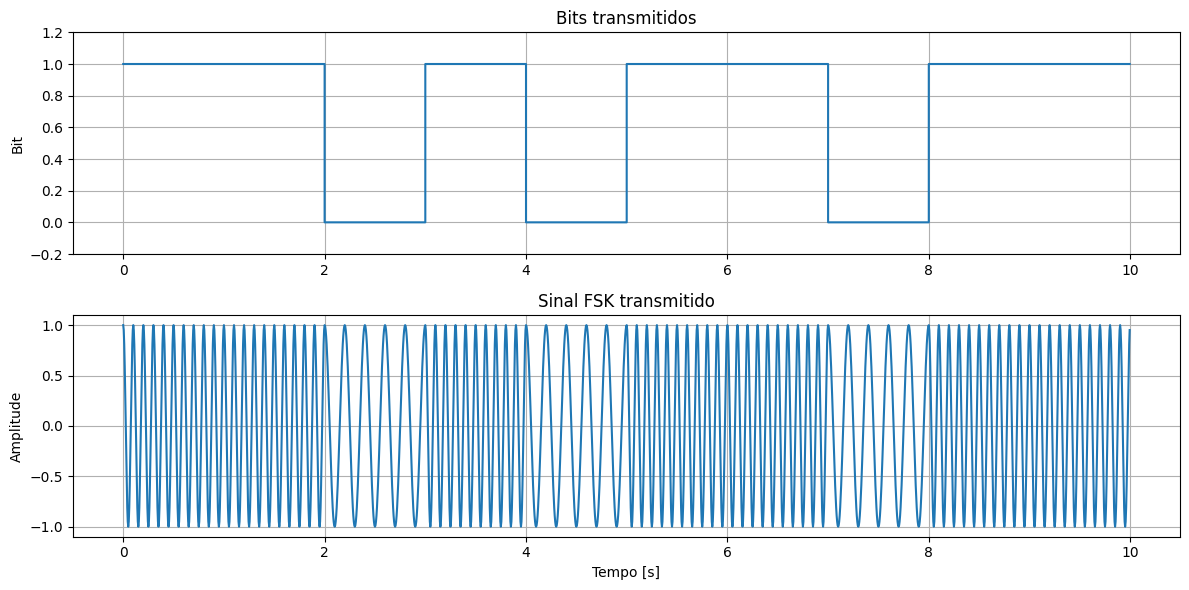

In [4]:
# Vetor de tempo para apenas um intervalo de bit.
t_bit = np.arange(samples_per_bit) / fs

# Lista que recebera os trechos de senoide de cada bit.
sinal_fsk = []

# Para cada bit, escolhe a frequencia correspondente e gera a portadora.
for bit in bits:
    # Se o bit for 0, usa a frequencia f0.
    if bit == 0:
        portadora = A * np.cos(2 * np.pi * f0 * t_bit)
    # Se o bit for 1, usa a frequencia f1.
    else:
        portadora = A * np.cos(2 * np.pi * f1 * t_bit)

    # Adiciona o trecho gerado ao sinal FSK completo.
    sinal_fsk.extend(portadora)

# Converte a lista final para vetor numpy.
sinal_fsk = np.array(sinal_fsk)

# Vetor de tempo para o sinal FSK completo.
t = np.arange(len(sinal_fsk)) / fs

# Repete cada bit para permitir a visualizacao da sequencia no tempo.
bits_plot = np.repeat(bits, samples_per_bit)

# Cria uma figura com dois graficos.
plt.figure(figsize=(12, 6))

# Grafico da sequencia de bits transmitidos.
plt.subplot(2, 1, 1)
plt.step(t, bits_plot, where='post')
plt.title('Bits transmitidos')
plt.ylabel('Bit')
plt.ylim(-0.2, 1.2)
plt.grid(True)

# Grafico do sinal FSK gerado a partir da sequencia de bits.
plt.subplot(2, 1, 2)
plt.plot(t, sinal_fsk)
plt.title('Sinal FSK transmitido')
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude')
plt.grid(True)

# Ajusta o espacamento entre os graficos e exibe a figura.
plt.tight_layout()
plt.show()

### Canal com ruido

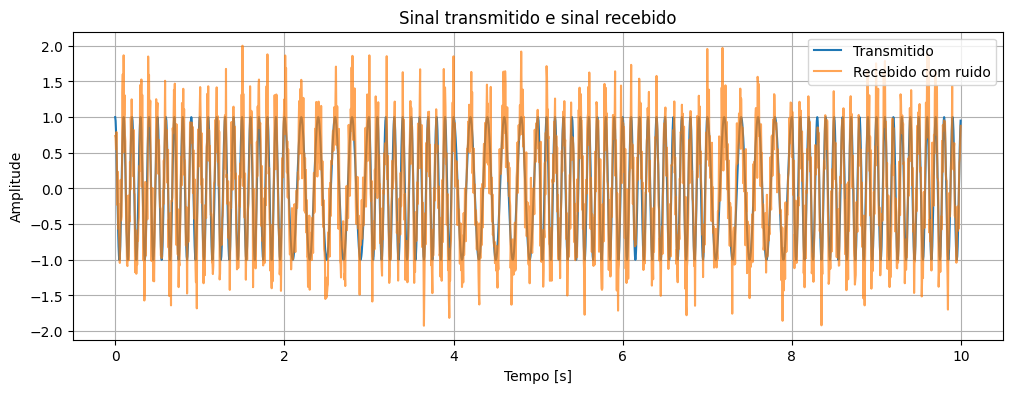

In [5]:
# SNR usada no canal, em dB.
snr_db = 5

# Calcula a potencia media do sinal transmitido.
potencia_sinal = np.mean(sinal_fsk**2)

# Converte SNR de dB para escala linear.
snr_linear = 10**(snr_db / 10)

# Calcula a potencia de ruido necessaria para obter a SNR desejada.
potencia_ruido = potencia_sinal / snr_linear

# Gera ruido gaussiano branco com media zero.
ruido = np.sqrt(potencia_ruido) * np.random.normal(0, 1, len(sinal_fsk))

# O sinal recebido e a soma do sinal transmitido com o ruido do canal.
sinal_recebido = sinal_fsk + ruido

# Compara graficamente o sinal transmitido com o sinal recebido.
plt.figure(figsize=(12, 4))
plt.plot(t, sinal_fsk, label='Transmitido')
plt.plot(t, sinal_recebido, label='Recebido com ruido', alpha=0.7)
plt.title('Sinal transmitido e sinal recebido')
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

### Recepcao do sinal FSK

O receptor compara cada intervalo de bit com duas referencias: uma em `f0` e outra em `f1`. A maior correlacao define o bit recebido.

In [6]:
# Referencia que o receptor espera quando o bit transmitido e 0.
referencia_0 = np.cos(2 * np.pi * f0 * t_bit)

# Referencia que o receptor espera quando o bit transmitido e 1.
referencia_1 = np.cos(2 * np.pi * f1 * t_bit)

# Lista que armazenara os bits estimados pelo receptor.
bits_recebidos = []

# Analisa o sinal recebido em blocos, um bloco para cada bit.
for i in range(N_bits):
    # Define o inicio e o fim do trecho correspondente ao bit atual.
    inicio = i * samples_per_bit
    fim = inicio + samples_per_bit

    # Extrai do sinal recebido apenas o trecho do bit atual.
    trecho = sinal_recebido[inicio:fim]

    # Mede a semelhanca do trecho recebido com a referencia de bit 0.
    correlacao_0 = np.sum(trecho * referencia_0)

    # Mede a semelhanca do trecho recebido com a referencia de bit 1.
    correlacao_1 = np.sum(trecho * referencia_1)

    # Se a correlacao com f1 for maior, decide que o bit recebido foi 1.
    if correlacao_1 > correlacao_0:
        bits_recebidos.append(1)
    # Caso contrario, decide que o bit recebido foi 0.
    else:
        bits_recebidos.append(0)

# Converte a lista de bits estimados para vetor numpy.
bits_recebidos = np.array(bits_recebidos)

# Calcula a taxa de erro de bits comparando transmissao e recepcao.
ber = np.mean(bits != bits_recebidos)

# Mostra a sequencia transmitida.
print('Bits transmitidos:')
print(bits)

# Mostra a sequencia estimada pelo receptor.
print('\nBits recebidos:')
print(bits_recebidos)

# Mostra a taxa de erro de bits da simulacao.
print(f'\nTaxa de erro de bits = {ber:.4f}')

Bits transmitidos:
[1 1 0 1 0 1 1 0 1 1]

Bits recebidos:
[1 1 0 1 0 1 1 0 1 1]

Taxa de erro de bits = 0.0000
